# Day 1 — Unsupervised Learning & K-Means Clustering

This notebook focuses on applying K-Means clustering to customer data.

The workflow includes data loading, feature selection, missing-value checking, feature scaling, selecting the optimal number of clusters using the Elbow Method and Silhouette Score, training the final K-Means model, visualizing the clusters, and interpreting the resulting customer segments.

## Step 1 — Import Required Libraries

The required libraries are imported for data manipulation, visualization, clustering, feature scaling, and cluster evaluation.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


## Step 2 — Load the Dataset

The Mall Customers dataset is loaded into a Pandas DataFrame.

The dataset contains customer demographic information, annual income, and spending score, which can be used to identify different customer segments.

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


## Step 3 — Inspect Dataset Columns

The column names are inspected to understand the available variables and identify the features that can be used for clustering.

In [4]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')

## Step 4 — Select Clustering Features

Three numerical features are selected for clustering:

- `Age`
- `Annual Income (k$)`
- `Spending Score (1-100)`

`CustomerID` is excluded because it is only an identifier and does not provide meaningful information for clustering.

`Gender` is also excluded because the clustering analysis is performed using numerical features.

In [5]:
features = [
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]

X = df[features]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


## Step 5 — Check for Missing Values

Before applying scaling and clustering, the selected features are checked for missing values.

Missing values can affect the clustering process, so this step verifies that the selected features are complete.

In [7]:
X.isnull().sum()

Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

No missing values were found in the selected clustering features, so no missing-value treatment is required before scaling.

## Step 6 — Feature Scaling

The selected features are standardized using `StandardScaler`.

Scaling is important for K-Means because the algorithm is distance-based. Without scaling, features with larger numerical ranges could have a greater influence on the clustering results.

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

## Step 7 — Elbow Method

The Elbow Method is used to explore different values of `k`, the number of clusters.

K-Means is fitted for values of `k` from 1 to 10, and the inertia is recorded for each value.

Inertia measures the total within-cluster variation. As the number of clusters increases, inertia decreases. The goal is to identify the point where the improvement starts to decrease noticeably, forming an elbow in the plot.

In [14]:
inertias = []

for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(x_scaled)
    
    inertias.append(kmeans.inertia_)

## Step 8 — Visualize the Elbow Method

The inertia values are plotted against the number of clusters.

The plot is used to identify reasonable candidate values for `k` before applying the Silhouette Score as a quantitative comparison.

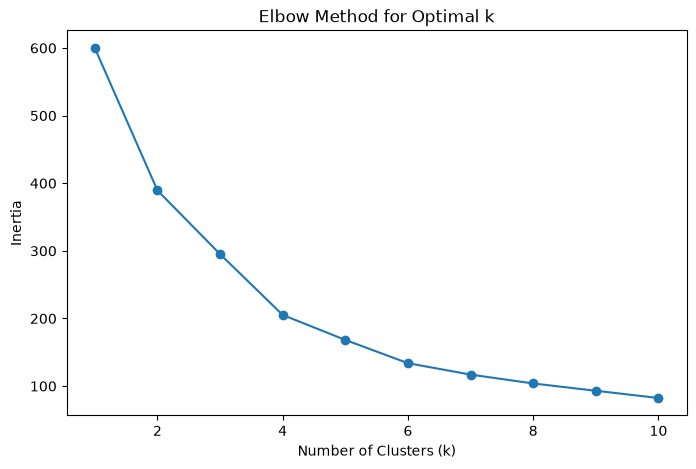

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")

plt.show()

### Elbow Method Observation

The Elbow Method suggests that values around `k = 4` and `k = 5` are reasonable candidates for the number of customer clusters.

The Silhouette Score will be used to compare these candidate values more quantitatively.

## Step 9 — Compare Candidate k Values Using Silhouette Score

The Silhouette Score is calculated for the two candidate values identified from the Elbow Method: `k = 4` and `k = 5`.

The Silhouette Score ranges from -1 to 1, where a higher score indicates better-defined and more separated clusters.

The candidate with the higher score will be selected for the final K-Means model.

In [17]:
candidate_k = [4, 5]

silhouette_scores = {}

for k in candidate_k:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(x_scaled)
    
    score = silhouette_score(
        x_scaled,
        labels
    )
    
    silhouette_scores[k] = score
    
    print(f"k = {k}, Silhouette Score = {score:.4f}")

k = 4, Silhouette Score = 0.4040
k = 5, Silhouette Score = 0.4166


## Step 10 — Select the Best Number of Clusters

The Silhouette Scores are compared to select the final value of `k`.

The results are:

- `k = 4` → Silhouette Score = `0.4040`
- `k = 5` → Silhouette Score = `0.4166`

Since `k = 5` has the higher Silhouette Score, five clusters are selected for the final K-Means model.

In [18]:
best_k = 5

## Step 11 — Train the Final K-Means Model

A final K-Means model is trained using the selected value of `k = 5`.

The cluster labels generated by the model are then added to the original DataFrame so that each customer can be associated with a cluster.

In [20]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

cluster_labels = final_kmeans.fit_predict(x_scaled)

In [30]:
df["Cluster"] = cluster_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


## Step 12 — Visualize Customer Clusters

The customer clusters are visualized using Annual Income and Spending Score.

Each point represents a customer, and the color indicates the cluster assigned by K-Means.

This visualization helps show the separation between different customer segments based on income and spending behavior.

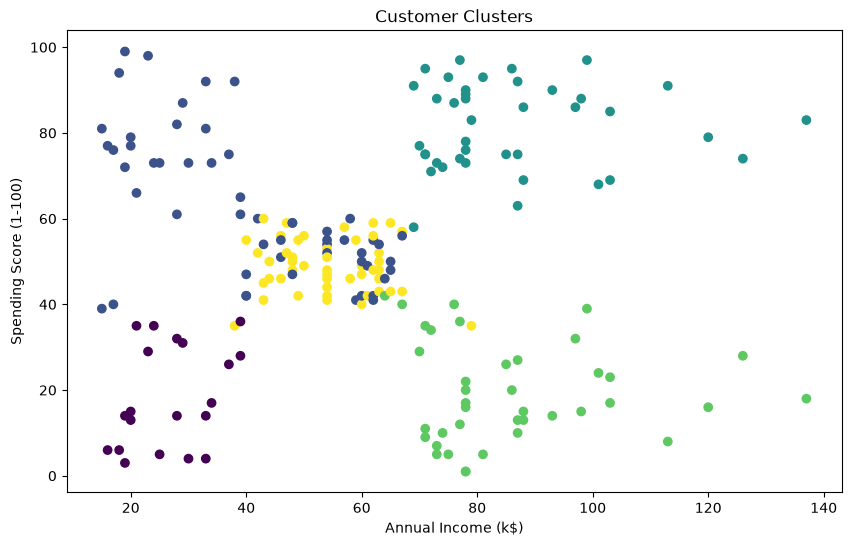

In [24]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters")

plt.show()

### Cluster Visualization

The scatter plot visualizes the five customer clusters identified by K-Means using Annual Income and Spending Score.

Each point represents one customer, while different colors represent different clusters.

The plot shows that customers are grouped according to similarities in their income and spending behavior. For example, some groups contain customers with high income and high spending, while others contain high-income customers with relatively low spending.

This visualization provides a clear view of the different customer segments discovered by the clustering algorithm.

## Step 13 — Visualize Cluster Centroids

The K-Means cluster centers are transformed back to the original feature scale using the inverse transformation of `StandardScaler`.

The centroids are then plotted together with the customer points to show the central position of each cluster.

In [25]:
centroids = scaler.inverse_transform(
    final_kmeans.cluster_centers_
)

## Step 14 — Customer Clusters with Centroids

The customer clusters are plotted again with the cluster centroids highlighted using `X` markers.

The centroids represent the average position of the customers within each cluster in the original feature space.

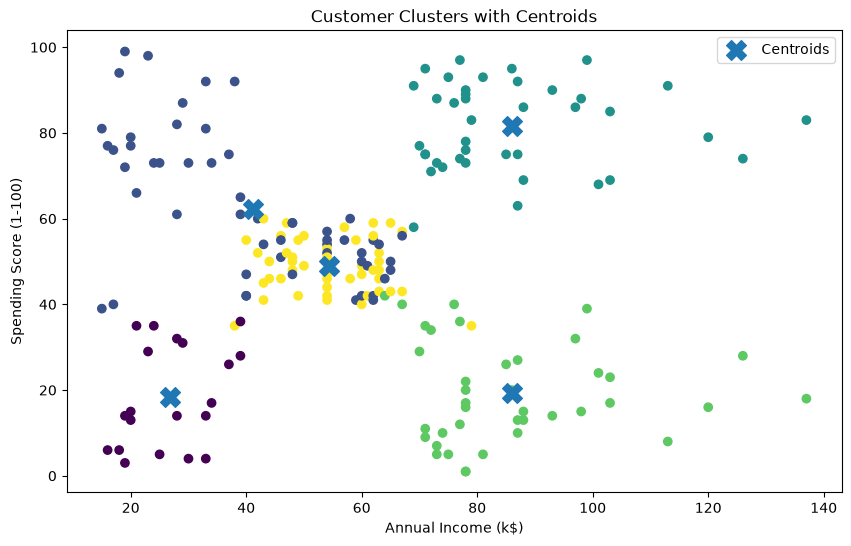

In [26]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    centroids[:, 1],
    centroids[:, 2],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters with Centroids")

plt.legend()

plt.show()

### Cluster Visualization with Centroids

The second plot shows the same customer clusters together with their centroids, represented by the large `X` markers.

Each centroid represents the average position of the customers belonging to its cluster in terms of Age, Annual Income, and Spending Score.

The centroids help identify the central characteristics of each customer segment and make it easier to understand how K-Means separates the customers into five groups.

Overall, the visualization confirms that the clusters have distinct spending and income patterns.

## Step 15 — Summarize the Customer Clusters

To better understand the characteristics of each cluster, the average age, average annual income, average spending score, and number of customers are calculated for each cluster.

This summary provides a numerical basis for interpreting the customer segments.

In [28]:
cluster_summary = df.groupby("Cluster").agg(
    Customers=("Cluster", "size"),
    Average_Age=("Age", "mean"),
    Average_Income=("Annual Income (k$)", "mean"),
    Average_Spending=("Spending Score (1-100)", "mean")
)

cluster_summary

,Customers,Average_Age,Average_Income,Average_Spending
Cluster,,,,
0,20,46.250000,26.750000,18.350000
1,54,25.185185,41.092593,62.240741
2,40,32.875000,86.100000,81.525000
3,39,39.871795,86.102564,19.358974
4,47,55.638298,54.382979,48.851064


## Step 16 — Cluster Interpretation

Based on the cluster summary, the five customer segments can be interpreted as follows:

### Cluster 0 — Older, Lower-Income, Low-Spending Customers
This cluster contains 20 customers with an average age of approximately 46 years, an average annual income of about 27 k$, and a low average spending score of about 18.

These customers represent a lower-income group with relatively low spending behavior.

### Cluster 1 — Young, Moderate-Income, High-Spending Customers
This cluster contains 54 customers with an average age of approximately 25 years, an average annual income of about 41 k$, and an average spending score of about 62.

These customers are relatively young and show higher spending behavior compared with their income level.

### Cluster 2 — Higher-Income, High-Spending Customers
This cluster contains 40 customers with an average age of approximately 33 years, an average annual income of about 86 k$, and a high average spending score of about 82.

This group represents high-value customers because they combine relatively high income with high spending.

### Cluster 3 — Higher-Income, Low-Spending Customers
This cluster contains 39 customers with an average age of approximately 40 years, an average annual income of about 86 k$, and a low average spending score of about 19.

These customers have relatively high income but low spending behavior, making them a potentially important segment for targeted marketing strategies.

### Cluster 4 — Older, Moderate-Income, Moderate-Spending Customers
This cluster contains 47 customers with an average age of approximately 56 years, an average annual income of about 54 k$, and an average spending score of about 49.

These customers are generally older and have moderate income and spending behavior.

Overall, K-Means identified five distinct customer segments based on age, annual income, and spending score.

## Conclusion

K-Means clustering was successfully applied to segment customers based on their age, annual income, and spending score.

The features were standardized before clustering to ensure that differences in feature scales did not disproportionately affect the distance calculations.

The Elbow Method was used to identify reasonable candidate values for `k`, and the Silhouette Score was then used to compare `k = 4` and `k = 5`.

Since `k = 5` achieved the higher Silhouette Score of `0.4166`, five clusters were selected for the final model.

The resulting clusters represent different customer segments with distinct demographic and spending characteristics.